In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms

In [ ]:
#getting dataset
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor()
)

In [ ]:
image, label = train_data[0]
print(f"Image type: {type(image)}")
print(f"Image shape: {image.shape}")
print(f"Label type: {type(label)}")
print(f"Label: {label}")

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([1, 28, 28])
Label type: <class 'int'>
Label: 9


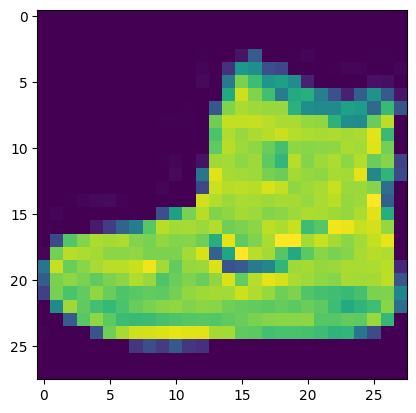

In [ ]:
#visualize the data
import matplotlib.pyplot as plt
image , label = train_data[0]
plt.imshow(image.squeeze())
# plt.figure(figsize=(10,10))



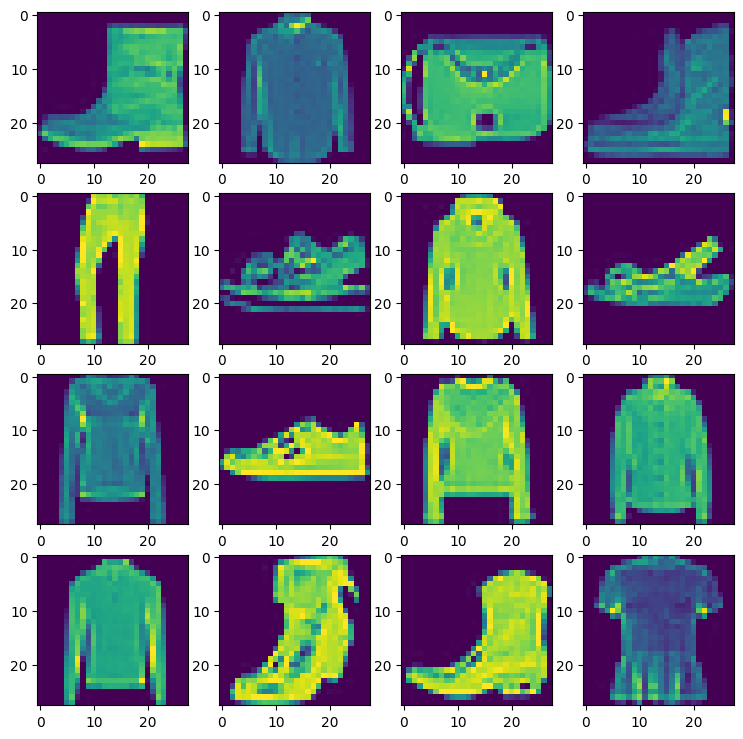

In [ ]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9 , 9))

for i in range(1 , 17):
  random_index = torch.randint(0 , len(train_data) , size = [1]).item()
  image , label  = train_data[random_index]
  fig.add_subplot(4 , 4 , i)
  plt.imshow(image.squeeze())


In [ ]:
#dviding the dataset into batchsize of 32
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

# Redefining train_data and test_data to ensure they are in scope
# train_data = datasets.FashionMNIST(
#     root="data",
#     train=True,
#     download=True,
#     transform=torchvision.transforms.ToTensor(),
# )
# test_data = datasets.FashionMNIST(
#     root="data",
#     train=False,
#     download=True,
#     transform=torchvision.transforms.ToTensor()
# )

BATCH_SIZE=32

train_dataloader = DataLoader(dataset=train_data , batch_size =BATCH_SIZE , shuffle=True)
test_dataloader = DataLoader(dataset=test_data , batch_size=BATCH_SIZE , shuffle=False)
train_dataloader , test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c43284365a0>,
 <torch.utils.data.dataloader.DataLoader at 0x7c432830c830>)

In [ ]:
train_features_batch , train_labels_batch = next(iter(train_dataloader))


6


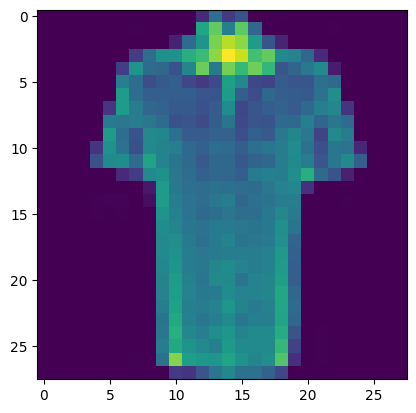

In [ ]:

torch.manual_seed(42)
# for i in range(0 , 32):
random_index = torch.randint(0 , len(train_features_batch) , size=[1]).item()
img , label = train_features_batch[random_index] , train_labels_batch[random_index]
plt.imshow(img.squeeze())
print(random_index)

In [ ]:
class FashionMNISTV2(nn.Module):
  def __init__(self , input_shape , hidden_units , output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape , out_channels=hidden_units , kernel_size=3 ,stride=1 , padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units , out_channels= output_shape , kernel_size=3 , stride=1 , padding= 1 )  ,
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 , stride=2)
        )
    self.conv_block_2 =nn.Sequential(
        nn.Conv2d(in_channels=output_shape , out_channels=hidden_units , kernel_size=3 ,stride=1 , padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units , out_channels= output_shape , kernel_size=3 , stride=1 , padding= 1 )  ,
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 , stride=2)
        )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=output_shape * 7 * 7 , out_features=output_shape)
    )
  def forward(self , x:torch.Tensor):
    x=self.conv_block_1(x)
    # print(f"1 {x.shape}")
    x=self.conv_block_2(x)

    # print(f"2 {x.shape}")
    x=self.classifier(x)
    # print(f"3 {x.shape}")
    return x

In [ ]:

torch.manual_seed(42)
image = torch.randn(size= (32 , 3 , 64 , 64))
test_image = image[0]
print({image.shape})
print({test_image.shape})
# print({test_image})
maxpoollayer = nn.MaxPool2d(kernel_size=2 , stride=2)
maxpoollayer(test_image)
# maxpoollayer(image)

{torch.Size([32, 3, 64, 64])}
{torch.Size([3, 64, 64])}


tensor([[[ 1.9269,  2.2181,  0.6784,  ...,  0.7642,  1.8446,  1.3835],
         [ 1.9312,  0.9624,  1.6354,  ...,  0.8539,  1.0229,  0.7099],
         [ 0.5636,  1.0554,  0.4652,  ...,  0.4485,  0.8541,  1.2049],
         ...,
         [ 1.1233,  2.1158,  1.4051,  ...,  1.4307,  1.9144,  1.5664],
         [ 0.0515,  1.0802,  1.7977,  ...,  0.9106,  0.9991,  0.2425],
         [ 0.3076,  0.6421,  0.9172,  ...,  0.3761,  2.6678,  0.9416]],

        [[ 2.0818,  2.0741,  1.7054,  ...,  1.1078,  1.6612, -0.4319],
         [-0.1010,  0.8919,  0.5042,  ...,  0.5441,  1.2990,  1.8377],
         [ 0.6289,  1.0303,  0.1668,  ...,  1.2482,  2.4611,  1.8377],
         ...,
         [ 1.6984,  0.1371,  1.2942,  ...,  1.3265,  1.5168,  0.8127],
         [ 0.7342,  2.1091, -0.4260,  ...,  0.2568, -0.0400,  0.5846],
         [ 0.7205,  1.6574,  1.1300,  ...,  0.2673,  0.5409,  2.2465]],

        [[ 1.0261,  1.1465,  1.2445,  ...,  1.1764,  1.2134,  0.9354],
         [ 0.8466,  1.3186,  1.6730,  ...,  1

Text(0.5, 1.0, 'Label: 5')

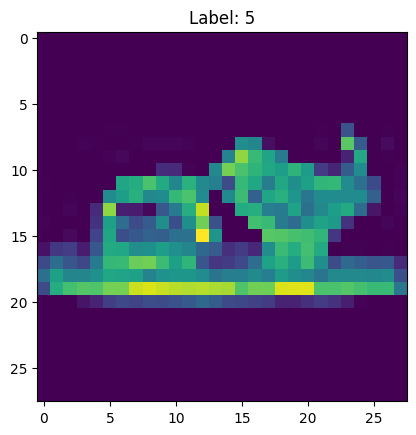

In [ ]:
# torch.random.manual_seed(43)
random_index = torch.randint(0 , len(train_data) , size=[1]).item()
image , label = train_data[random_index]
plt.imshow(image.squeeze())
plt.title(f"Label: {label}")


In [ ]:
torch.manual_seed(42)
model2 = FashionMNISTV2(input_shape=1 , hidden_units=10 , output_shape=len(class_names)).to(device)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class_names = train_data.classes
print(f"Class names: {class_names}")

Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
model2.eval()
with torch.inference_mode():
  # Get a single image from the train_data, which has 1 channel
  # and add a batch dimension for model input.
  test_image_single_channel = train_data[0][0].unsqueeze(0).to(device)
  pred = model2(test_image_single_channel)
  pred_label = class_names[pred.argmax(dim=1)]

pred_label , class_names[label]

('Pullover', 'Sandal')

In [ ]:
rand_image_tensor = torch.randn(size = (1 , 28 , 28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
model2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
#seting up the train and test for the model


In [ ]:
 loss_fn = nn.CrossEntropyLoss()
 optimizer = torch.optim.SGD(params = model2.parameters() , lr =0.01)

In [ ]:
import tqdm
torch.manual_seed(42)
epochs = 3
for epoch in tqdm.tqdm(range(epochs)): # Corrected: using tqdm.tqdm
  print(f"Epoch: {epoch}\n---------")
  train_step(model = model2 , data_loader = train_dataloader , loss_fn = loss_fn , accuracy_fn = accuracy_fn , optimizer = optimizer)
  test_step(model = model2 , data_loader = test_dataloader , loss_fn = loss_fn , accuracy_fn = accuracy_fn)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.03780 | Train accuracy: 62.34%


 33%|███▎      | 1/3 [00:11<00:22, 11.38s/it]

Test loss: 0.62501 | Test accuracy: 76.87%

Epoch: 1
---------
Train loss: 0.54940 | Train accuracy: 80.01%


 67%|██████▋   | 2/3 [00:22<00:11, 11.34s/it]

Test loss: 0.49808 | Test accuracy: 81.50%

Epoch: 2
---------
Train loss: 0.45562 | Train accuracy: 83.49%


100%|██████████| 3/3 [00:34<00:00, 11.34s/it]

Test loss: 0.44004 | Test accuracy: 84.23%



In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [ ]:
def train_step(model: nn.Module, data_loader: DataLoader, loss_fn: nn.Module, accuracy_fn, optimizer: torch.optim.Optimizer, device: torch.device = device):
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

In [ ]:
def test_step(model: nn.Module, data_loader: DataLoader, loss_fn: nn.Module, accuracy_fn, device: torch.device = device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [ ]:
FashionMNISTV2.state_dict

<function torch.nn.modules.module.Module.state_dict(self, *args, destination=None, prefix='', keep_vars=False)>